In [10]:
!pip install cmake opencv-python
!conda install -y dlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.5/29.5 MB 38.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 42.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [cmake]32m1/2 [cmake]
Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /opt/conda

  added / updated specs:
    - dlib


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.6.17  |       hbd8a1cb_0         126 KB  conda-forge
    certifi-2026.6.17          |     pyhd8ed1ab_0         131 KB  conda-forge
    dlib-20.0.0                |cpu_py312hb8e531a_0         3.3 MB  conda-forge
    openssl-3.6.3

In [19]:
import os
import cv2
import dlib
import matplotlib.pyplot as plt # 다양한 데이터를 많은 방법으로 도식화 할 수 있도록 하는 라이브러리
import numpy as np

print(cv2.__version__)
print(dlib.__version__)

4.13.0
20.0.0


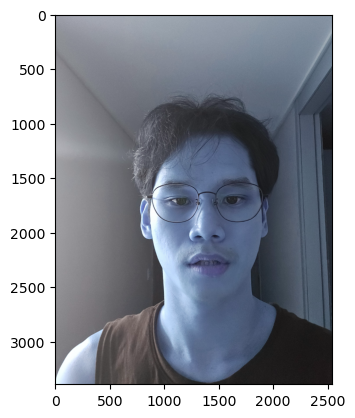

In [95]:
home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, 'work/camera_sticker/images/image.png') # 본인 이미지가 있는 경로를 가지고 온다.
img_bgr = cv2.imread(my_image_path)    # OpenCV로 이미지를 불러옵니다
img_show = img_bgr.copy()      # 출력용 이미지를 따로 보관합니다
plt.imshow(img_bgr) # 이미지를 출력하기 위해 출력할 이미지를 올려준다. (실제 출력은 하지 않음)


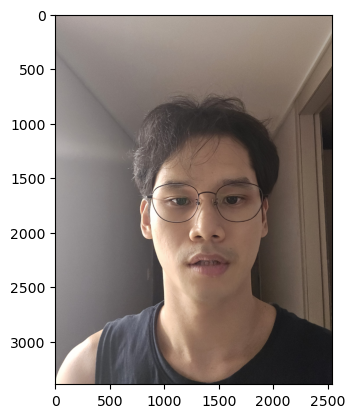

In [96]:
# plt.imshow 이전에 RGB 이미지로 바꾸는 것을 잊지마세요.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) # 이미지 실제 출력하기 위해 이미지를 올려줌 (원하는 사이즈의 픽셀을 원하는 색으로 채워서 만든 그림이라고 합니다.)
plt.show() # 이미지 실제 출력

In [97]:
# detector를 선언합니다
detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환

In [98]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)   # (image, num of image pyramid)

rectangles[[(869, 1380) (2019, 2530)]]


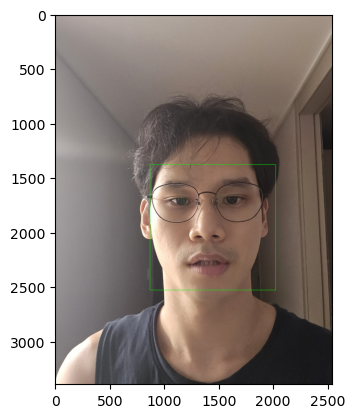

In [99]:
print(dlib_rects)

for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

In [74]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat.bz2 ~/work/camera_sticker/models
!cd ~/work/camera_sticker && bzip2 -d ./models/shape_predictor_68_face_landmarks.dat.bz2

--2026-06-22 06:45:08--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-06-22 06:45:08--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  14.5MB/s    in 5.2s    

2026-06-22 06:45:14 (11.7 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

bzip2: Output file ./models/shape_predictor_68_face_landmarks.dat already exists.


In [100]:
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')
    # 저장한 landmark 모델의 주소를 model_path 변수에 저장
landmark_predictor = dlib.shape_predictor(model_path)
    # dlib 라이브러리의 shape_predictor 함수를 이용하여 모델을 불러옴
    # landmark_predictor는 RGB이미지와 dlib.rectangle를 입력 받고 dlib.full_object_detection를 반환
    # dlib.rectangle: 내부를 예측하는 박스
    # dlib.full_object_detection: 각 구성 요소의 위치와, 이미지 상의 객체의 위치를 나타냄
print("🌫🛸")

🌫🛸


In [101]:
list_landmarks = []
    # 랜드마크의 위치를 저장할 list 생성

# 얼굴 영역 박스 마다 face landmark를 찾아냅니다
# face landmark 좌표를 저장해둡니다
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
        # 모든 landmark의 위치정보를 points 변수에 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
        # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_landmarks.append(list_points)
        # list_landmarks에 랜드마크 리스트를 저장

print(len(list_landmarks[0]))
    # 얼굴이 n개인 경우 list_landmarks는 n개의 원소를 갖고
    # 각 원소는 68개의 랜드마크 위치가 나열된 list
    # list_landmarks의 원소가 1개이므로 list_landmarks[1]을 호출하면 IndexError가 발생

68


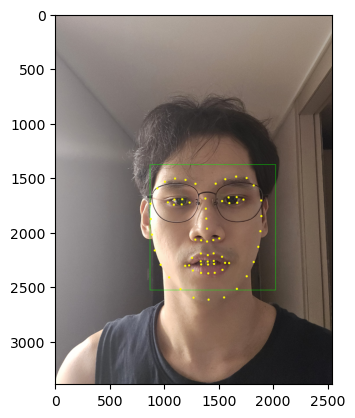

In [102]:
# list_landmarks의 원소가 1개이므로 아래 반복문은 한번만 실행됨
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 10, (0, 255, 255), -1)  ## 사진 해상도가 커 점의 크기를 10으로 늘림
            # cv2.circle: OpenCV의 원을 그리는 함수
            # img_show 이미지 위 각각의 point에
            # 크기가 2이고 (0, 255, 255)색으로 내부가 채워진(-1) 원을 그림
            # (마지막 인수가 자연수라면 그만큼의 두께의 선으로 원이 그려짐)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
    # RGB 이미지로 전환
plt.imshow(img_show_rgb)
    # 이미지를 준비
plt.show()
    # 이미지를 출력

In [103]:
# zip() : 두 그룹의 데이터를 서로 엮어주는 파이썬의 내장 함수
# dlib_rects와 list_landmarks 데이터를 엮어 주었음
# dlib_rects : 얼굴 영역을 저장하고 있는 값

# list_landmarks : 68개의 랜드마크 값 저장(이목구비 위치(x,y))

for dlib_rect, landmark in zip(dlib_rects, list_landmarks): # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
    print (landmark[30]) # 코의 index는 30 입니다
    x = landmark[33][0]
    y = landmark[33][1] - img_sticker.shape[0] // 2
    w = h = dlib_rect.width() # 얼굴 영역의 가로를 차지하는 픽셀의 수 (531-345+1) → max(x) - min(x) +1(픽셀의 수 이기 때문에 1을 더해줌 → 픽셀 수는 점 하나로도 1이 됨)
    print (f'(x,y) : ({x},{y})')
    print (f'(w,h) : ({w},{h})')

(1390, 1967)
(x,y) : (1391,1510)
(w,h) : (1151,1151)


In [79]:
sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/cat.png') # 왕관 이미지의 경로
img_sticker = cv2.imread(sticker_path) # 스티커 이미지를 불러옵니다 // cv2.imread(이미지 경로) → image객체 행렬을 반환
img_sticker = cv2.resize(img_sticker, (w,h)) # 스티커 이미지 조정 → w,h는 얼굴 영역의 가로를 차지하는 픽셀의 수(187) // cv2.resize(image객체 행렬, (가로 길이, 세로 길이))
print (img_sticker.shape) # 사이즈를 조정한 고양이 수염 이미지의 차원 확인

(1151, 1151, 3)


In [105]:

# 스티커가 시작될 좌상단(top-left) 좌표 설정
refined_x = x - w // 2  
refined_y = y  # 89-187 = -98

# 원본 이미지에 스티커 이미지를 추가하기 위해서 x, y 좌표를 조정합니다. 이미지 시작점은 top-left 좌표이기 때문입니다.
# 즉, refined_x, refined_y값에서 왕관 이미지가 시작됨
print (f'(x,y) : ({refined_x},{refined_y})') 

(x,y) : (816,1510)


In [106]:

# 2. 이미지 경계 예외 처리 (스티커가 화면 밖으로 나가는 경우 방지)
if refined_x < 0: refined_x = 0
if refined_y < 0: refined_y = 0

# 3. 원본 이미지에서 스티커를 적용할 위치 잘라내기 (crop)
sticker_area = img_show[refined_y:refined_y + img_sticker.shape[0], refined_x:refined_x + img_sticker.shape[1]]

# 4. [수정] cv2.addWeighted를 활용해 '수염 부분만' 원본과 반투명하게 합성하기
# 투명도 조절: 원본 비율 0.4 + 스티커 비율 0.6 (이 숫자를 조절해서 진하기를 바꿀 수 있습니다!)
blended_area = cv2.addWeighted(sticker_area, 0.4, img_sticker, 0.6, 0)

# 5. np.where로 흰색 배경(255)은 원본(sticker_area)을 보여주고, 수염 부분은 반투명해진 blended_area를 보여줌
img_show[refined_y:refined_y + img_sticker.shape[0], refined_x:refined_x + img_sticker.shape[1]] = \
    np.where(img_sticker == 255, sticker_area, blended_area).astype(np.uint8)

print("슝~")

슝~


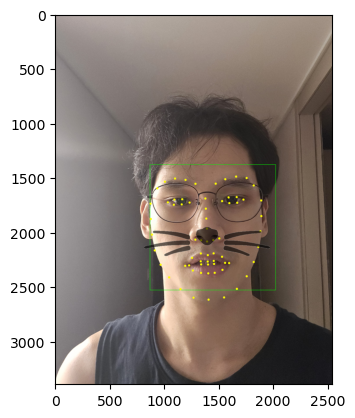

In [107]:
# 왕관 이미지를 적용한 이미지를 보여준다.
# 얼굴 영역(7-3)과 랜드마크(7-4)를 미리 적용해놓은 img_show에 왕관 이미지를 덧붙인 이미지가 나오게 된다.)
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

## 랜드마크, 박스 제거

In [108]:
img_show = img_bgr.copy()

# 2. 이미지 경계 예외 처리 (기존 동일)
if refined_x < 0: refined_x = 0
if refined_y < 0: refined_y = 0

# 3. 원본 이미지에서 스티커를 적용할 위치 잘라내기 (기존 동일)
sticker_area = img_show[refined_y:refined_y + img_sticker.shape[0], refined_x:refined_x + img_sticker.shape[1]]

# 4. cv2.addWeighted를 활용해 '수염 부분만' 원본과 반투명하게 합성하기
blended_area = cv2.addWeighted(sticker_area, 0.4, img_sticker, 0.6, 0)

# 5. np.where로 흰색 배경(255)은 순수 원본(sticker_area)을 보여주고, 수염 부분은 반투명해진 blended_area를 보여줌
img_show[refined_y:refined_y + img_sticker.shape[0], refined_x:refined_x + img_sticker.shape[1]] = \
    np.where(img_sticker == 255, sticker_area, blended_area).astype(np.uint8)

print("슝~")

슝~


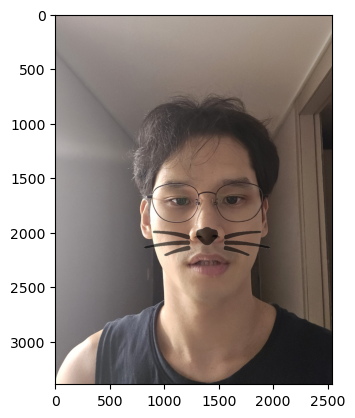

In [109]:
# 왕관 이미지를 적용한 이미지를 보여준다.
# 얼굴 영역(7-3)과 랜드마크(7-4)를 미리 적용해놓은 img_show에 왕관 이미지를 덧붙인 이미지가 나오게 된다.)
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

이미지 각도, 거리, 밝기를 변화시켜 보자

In [ ]:
1위: 얼굴의 각도 (가장 큰 영향 / 코드 수정 필요)
영향도: ★★★★★

이유: 현재 사용하신 dlib의 얼굴 검출기(get_frontal_face_detector)는 이름 그대로 '정면(Frontal) 얼굴' 위주로 학습되어 있습니다. 얼굴이 옆으로 많이 돌아가거나(측면), 고개를 위아래로 크게 꺾으면 dlib이 얼굴 사각형 자체를 찾지 못해 dlib_rects가 비어버리는 에러가 발생합니다.

코드 수정이 필요한 부분: 얼굴이 사선으로 기울어진 경우(도리도리나 갸우뚱), 수염 스티커도 그 각도만큼 회전시켜서 붙여야 합니다. 현재 코드는 스티커를 회전 없이 평평하게만 붙이므로, 얼굴이 기울어지면 수염만 혼자 똑바로 서 있는 어색한 상황이 연출됩니다. 이를 해결하려면 눈이나 입 꼬리의 각도를 계산해 스티커 이미지를 회전시키는 cv2.getRotationMatrix2D 같은 코드가 추가되어야 합니다.

2위: 사진 찍은 거리 (보통 영향 / 현재 코드로 방어 가능)
영향도: ★★★☆☆

이유: 카메라와 얼굴 사이의 거리가 멀어지면 얼굴이 작게 나오고, 가까워지면 얼굴이 크게 나옵니다.

이미 코드로 방어된 부분: 다행히 우리가 작성한 코드에는 w = h = dlib_rect.width()와 cv2.resize(img_sticker, (w, h))가 포함되어 있습니다. 거리가 달라져서 얼굴이 커지거나 작아지더라도, 얼굴 크기를 실시간으로 계산해 스티커 크기를 자동으로 조절해주므로 거리에 따른 에러는 거의 발생하지 않습니다. (다만, 너무 멀어져서 얼굴이 픽셀 수준으로 작아지면 인식이 안 될 수는 있습니다.)

3위: 이미지의 밝기 (비교적 적은 영향 / 딥러닝 체인지 필요)
영향도: ★★☆☆☆

이유: dlib의 HOG 알고리즘은 픽셀의 밝기 변화(경계선)를 감지하므로, 너무 어둡거나 그림자가 강하게 지면 눈, 코, 입의 경계를 놓칠 수 있습니다.

해결 방향: 이미지 밝기 때문에 인식이 안 될 때는 코드를 수정하기보다는 이미지 자체의 밝기를 전처리로 올려주거나(히스토그램 평활화 등), dlib 대신 조명 변화에 훨씬 강한 딥러닝 기반의 얼굴 검출기(예: MediaPipe, CNN 기반 검출기)로 모델 자체를 교체하는 것이 정답입니다.

In [112]:
!mv ~/work/camera_sticker/images/selfie.jpg ~/work/camera_sticker/images/selfie.png

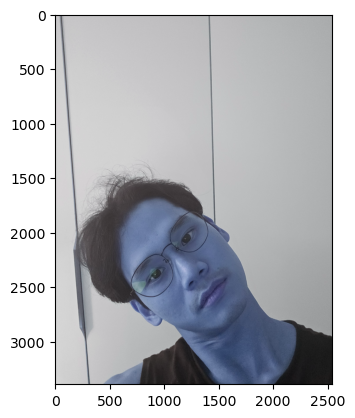

In [117]:
home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, 'work/camera_sticker/images/selfie.png') # 본인 이미지가 있는 경로를 가지고 온다.
img_bgr_angle = cv2.imread(my_image_path)    # OpenCV로 이미지를 불러옵니다
img_show_angle = img_bgr_angle.copy()      # 출력용 이미지를 따로 보관합니다
plt.imshow(img_bgr_angle) # 이미지를 출력하기 위해 출력할 이미지를 올려준다. (실제 출력은 하지 않음)


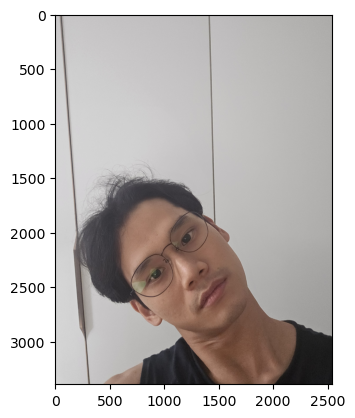

In [118]:
img_rgb_angle = cv2.cvtColor(img_bgr_angle, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb_angle) # 이미지 실제 출력하기 위해 이미지를 올려줌 (원하는 사이즈의 픽셀을 원하는 색으로 채워서 만든 그림이라고 합니다.)
plt.show() # 이미지 실제 출력

In [119]:
# detector를 선언합니다
detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환

In [120]:
img_rgb_angle = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb_angle, 1)   # (image, num of image pyramid)

rectangles[]


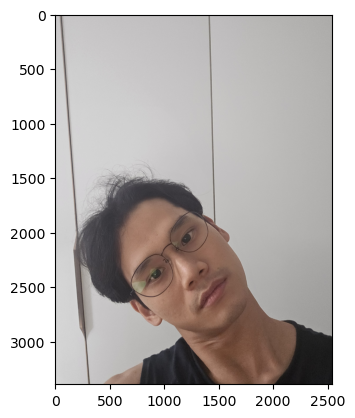

In [121]:
print(dlib_rects)

for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

img_show_rgb_angle =  cv2.cvtColor(img_show_angle, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb_angle)
plt.show()

얼굴을 인식하지 못하여, rectangles[]가 비어있는 리스트로 출력되었다.

# 회고
1. 얼굴 각도에 따라 스티커가 어떻게 변해야 할까요?  
답변: 얼굴이 좌우로 기울어지면(갸우뚱하면) 눈과 코의 위치도 같이 회전하게 됩니다. 따라서 스티커도 얼굴이 기울어진 각도만큼 회전(Rotate)해야 합니다.구현 방법: dlib 랜드마크 중 양쪽 눈의 중심점 좌표(landmark[36]와 landmark[45])를 이용해 기울어진 각도를 구한 뒤, OpenCV의 cv2.getRotationMatrix2D() 함수를 사용해 스티커 이미지를 그 각도만큼 회전시켜서 합성해야 자연스러워집니다.  
2. 멀리서 촬영하면 왜 안될까요?  
답변: 사진 속에서 얼굴이 차지하는 픽셀 수가 너무 적어지기 때문입니다. dlib의 HOG 필터나 랜드마크 모델은 눈, 코, 입의 선명한 경계선(Gradient) 특징을 기반으로 학습되었는데, 너무 멀리서 찍으면 얼굴의 세부 특징들이 뭉개져서 알고리즘이 얼굴이 아니라고 판단하거나 점의 위치를 엉뚱한 곳에 찍게 됩니다.  
3. 옆으로 누워서 촬영하면 왜 안될까요?  
답변: dlib의 기본 검출기(get_frontal_face_detector)가 '똑바로 서 있는 정면 얼굴' 데이터셋으로만 학습되었기 때문입니다. 사람이 옆으로 누우면 눈, 코, 입의 상대적인 위치 관계가 90도 돌아가게 되는데, dlib은 이를 얼굴의 구조로 인식하지 못해 방금 전처럼 rectangles[]를 빈 값으로 반환하게 됩니다.
5. 실행 속도가 중요할까요?  
답변: 매우 중요합니다. 이 스티커 앱이 사진 촬영용이라면 속도가 조금 느려도 괜찮지만, 인스타그램이나 스노우처럼 실시간 영상(동영상) 스트리밍 환경에서 작동하려면 최소 초당 30프레임(30 FPS) 이상을 처리해야 합니다. 즉, 얼굴을 찾고 스티커를 연산하는 데 0.03초 이상 걸리면 화면이 버벅거리기 때문에 모바일 환경에서는 가벼운 모델을 쓰는 것이 핵심입니다.
6. 스티커앱을 만들 때 정확도가 얼마나 중요할까요?  
답변: 사용자의 몰입감과 경험을 결정하는 가장 중요한 요소입니다. 얼굴을 조금만 움직여도 스티커가 덜덜 떨리거나(Jittering 현상), 코가 아니라 입술에 붙는 등 정확도가 떨어지면 사용자는 앱이 망가졌다고 느낍니다. 따라서 프레임 간의 좌표 오차를 부드럽게 보정해 주는 칼만 필터(Kalman Filter)나 광학 흐름(Optical Flow) 같은 보정 알고리즘을 섞어 정확도와 안정성을 높이는 것이 실제 상용 앱에서는 필수적입니다.